In [1]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
from distmesh import drectangle, huniform, distmesh2D

In [2]:
#params
epsilon = 0.01
tol = 1e-8 # tolerance
max_iter = 50 
h_step = 0.04 #step-size

count =  200 displacement =  0.012168586783411093
count =  400 displacement =  0.0034232089969463554
count =  600 displacement =  0.0037272056505444967
count =  800 displacement =  0.003385927624387421
count =  1000 displacement =  0.0026123859523727363
count =  1200 displacement =  0.0023135995093220927


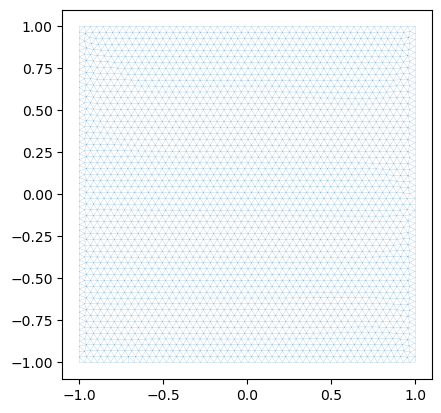

In [3]:
# mesh + IC + BCs
fd = lambda p: drectangle(p, -1, 1, -1, 1)
pfix = np.array([[-1, -1], [1, -1], [1, 1], [-1, 1]]) 
p, t = distmesh2D(fd, huniform, h_step, [-1, 1, -1, 1], pfix)

N = p.shape[0]

u = np.full(N, -1.0) #IC

#BC
d = fd(p)
boundary_indices = np.where(d > -0.001)[0]
free_indices = np.setdiff1d(np.arange(N), boundary_indices)
u[boundary_indices] = 0.0

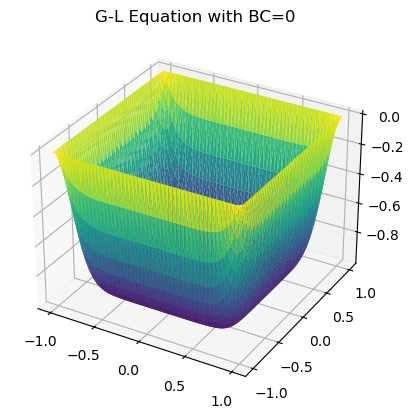

In [4]:
# solve part b using newton-raphson
for k in range(max_iter):
    A = sp.lil_matrix((N, N))
    b = np.zeros(N)
    
    for tri in t:
        nodes = tri
        coords = p[nodes]
        
        area = 0.5*np.abs(np.linalg.det(np.column_stack([np.ones(3), coords])))
        G = np.linalg.solve(np.column_stack([np.ones(3), coords]), np.eye(3))
        grad = G[1:3,:]
        
        # fem mats
        M_stiff = area * (grad.T@grad)
        M_mass = (area/12) * (np.ones((3, 3)) + np.eye(3))
        
        u_local = u[nodes]
        u_avg = np.mean(u_local)
        
        # J(u,v)
        J = epsilon * (M_stiff @ u_local) - (area/3)*(u_avg - u_avg**3)*np.ones(3)
        b[nodes] += J
        
        # DJ(u,v;w)
        dJ = epsilon*M_stiff - (1 - 3*u_avg**2)*M_mass
        A[np.ix_(nodes, nodes)] += dJ

    # Solve Newton update: DJ * W = J for free nodes
    W = np.zeros(N)
    A_free = A[np.ix_(free_indices, free_indices)].tocsr()
    W[free_indices] = spsolve(A_free, b[free_indices])
    
    # Update current iterate
    u -= W 
    
    error = np.linalg.norm(W)
    if error < tol:
        break
        
#plot sol to pde
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(p[:, 0], p[:, 1], u, triangles=t, cmap='viridis', edgecolor='none')
plt.title(f'G-L Equation with BC=0')
plt.show()

count =  200 displacement =  0.012168586783411093
count =  400 displacement =  0.0034232089969463554
count =  600 displacement =  0.0037272056505444967
count =  800 displacement =  0.003385927624387421
count =  1000 displacement =  0.0026123859523727363
count =  1200 displacement =  0.0023135995093220927


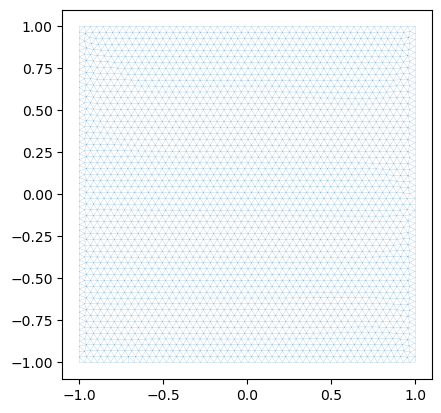

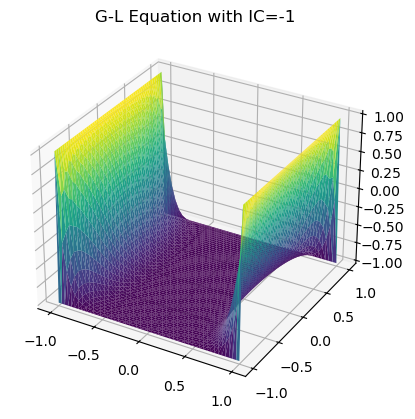

In [5]:
#Part E

def fd_rect(p):
    d1 = np.minimum(1 + p[:, 1], 1 - p[:, 1]) # distance to y=-1, y=1
    d2 = np.minimum(d1, 1 + p[:, 0])          # distance to x=-1
    return -np.minimum(d2, 1 - p[:, 0])       # distance to x=1

h0 = 0.04
pfix = np.array([[-1,-1], [1,-1], [1,1], [-1,1]])
p, t = distmesh2D(fd_rect, huniform, h0, [-1, 1, -1, 1], pfix)

N = p.shape[0]
u = np.full(N, -1.0) # IC: u = -1
d_val = fd_rect(p)
is_boundary = d_val > -0.005
boundary_nodes = np.where(is_boundary)[0]
free_nodes = np.where(~is_boundary)[0]

for i in boundary_nodes:
    x, y = p[i]
    if abs(y - 1) < 0.01 or abs(y + 1) < 0.01: # Top/Bottom
        u[i] = -1.0
    elif abs(x - 1) < 0.01 or abs(x + 1) < 0.01: # Left/Right
        u[i] = 1.0
        
# solve part b using newton-raphson
for k in range(max_iter):
    A = sp.lil_matrix((N, N))
    b = np.zeros(N)
    
    for tri in t:
        nodes = tri
        coords = p[nodes]
        
        area = 0.5*np.abs(np.linalg.det(np.column_stack([np.ones(3), coords])))
        G = np.linalg.solve(np.column_stack([np.ones(3), coords]), np.eye(3))
        grad = G[1:3,:]
        
        # fem mats
        M_stiff = area * (grad.T@grad)
        M_mass = (area/12) * (np.ones((3, 3)) + np.eye(3))
        
        u_local = u[nodes]
        u_avg = np.mean(u_local)
        
        # J(u,v)
        J = epsilon * (M_stiff @ u_local) - (area/3)*(u_avg - u_avg**3)*np.ones(3)
        b[nodes] += J
        
        # DJ(u,v;w)
        dJ = epsilon*M_stiff - (1 - 3*u_avg**2)*M_mass
        A[np.ix_(nodes, nodes)] += dJ

    # Solve Newton update: DJ * W = J for free nodes
    W = np.zeros(N)
    A_free = A[np.ix_(free_indices, free_indices)].tocsr()
    W[free_indices] = spsolve(A_free, b[free_indices])
    
    # Update current iterate
    u -= W 
    
    error = np.linalg.norm(W)
    if error < tol:
        break
        
#plot sol to pde
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(p[:, 0], p[:, 1], u, triangles=t, cmap='viridis', edgecolor='none')
plt.title(f'G-L Equation with IC=-1')
plt.show()

count =  200 displacement =  0.012168586783411093
count =  400 displacement =  0.0034232089969463554
count =  600 displacement =  0.0037272056505444967
count =  800 displacement =  0.003385927624387421
count =  1000 displacement =  0.0026123859523727363
count =  1200 displacement =  0.0023135995093220927


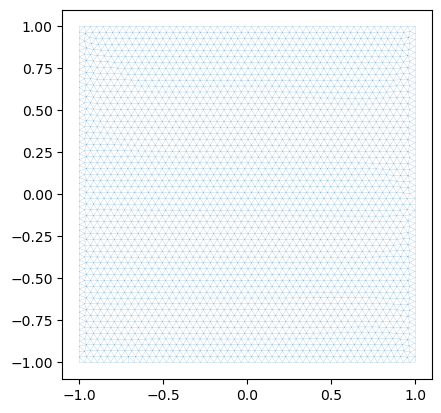

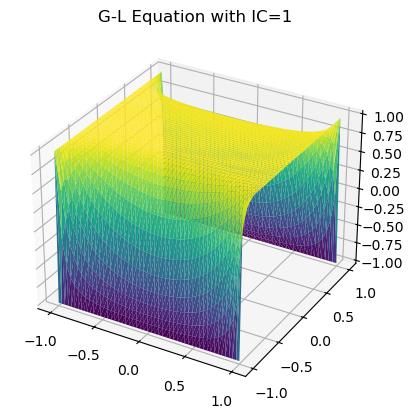

In [6]:
#Part E

def fd_rect(p):
    d1 = np.minimum(1 + p[:, 1], 1 - p[:, 1]) # distance to y=-1, y=1
    d2 = np.minimum(d1, 1 + p[:, 0])          # distance to x=-1
    return -np.minimum(d2, 1 - p[:, 0])       # distance to x=1

h0 = 0.04
pfix = np.array([[-1,-1], [1,-1], [1,1], [-1,1]])
p, t = distmesh2D(fd_rect, huniform, h0, [-1, 1, -1, 1], pfix)

N = p.shape[0]
u = np.full(N, 1.0) # IC: u = 1
d_val = fd_rect(p)
is_boundary = d_val > -0.005
boundary_nodes = np.where(is_boundary)[0]
free_nodes = np.where(~is_boundary)[0]

for i in boundary_nodes:
    x, y = p[i]
    if abs(y - 1) < 0.01 or abs(y + 1) < 0.01: # Top/Bottom
        u[i] = -1.0
    elif abs(x - 1) < 0.01 or abs(x + 1) < 0.01: # Left/Right
        u[i] = 1.0
        
# solve part b using newton-raphson
for k in range(max_iter):
    A = sp.lil_matrix((N, N))
    b = np.zeros(N)
    
    for tri in t:
        nodes = tri
        coords = p[nodes]
        
        area = 0.5*np.abs(np.linalg.det(np.column_stack([np.ones(3), coords])))
        G = np.linalg.solve(np.column_stack([np.ones(3), coords]), np.eye(3))
        grad = G[1:3,:]
        
        # fem mats
        M_stiff = area * (grad.T@grad)
        M_mass = (area/12) * (np.ones((3, 3)) + np.eye(3))
        
        u_local = u[nodes]
        u_avg = np.mean(u_local)
        
        # J(u,v)
        J = epsilon * (M_stiff @ u_local) - (area/3)*(u_avg - u_avg**3)*np.ones(3)
        b[nodes] += J
        
        # DJ(u,v;w)
        dJ = epsilon*M_stiff - (1 - 3*u_avg**2)*M_mass
        A[np.ix_(nodes, nodes)] += dJ

    # Solve Newton update: DJ * W = J for free nodes
    W = np.zeros(N)
    A_free = A[np.ix_(free_indices, free_indices)].tocsr()
    W[free_indices] = spsolve(A_free, b[free_indices])
    
    # Update current iterate
    u -= W 
    
    error = np.linalg.norm(W)
    if error < tol:
        break
        
#plot sol to pde
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(p[:, 0], p[:, 1], u, triangles=t, cmap='viridis', edgecolor='none')
plt.title(f'G-L Equation with IC=1')
plt.show()